In [1]:
from pynq import Overlay, allocate
import numpy as np
import matplotlib.pyplot as plt

# Load the overlay using your specific filenames
ol = Overlay("dac_adc.bit")

import xrfclk

# 1. Load Overlay and Setup Clocks
ol = Overlay("dac_adc.bit")
# Set reference clocks as per your working DAC script




In [2]:
xrfclk.set_ref_clks(lmk_freq=245.76, lmx_freq=491.52)
# Check if the blocks are detected (names should match your Vivado design)
print("IP Blocks found:", ol.ip_dict.keys())

# Create handles for the DMA and RFDC
dma = ol.axi_dma_0
rfdc = ol.usp_rf_data_converter_0

IP Blocks found: dict_keys(['axi_dma_0', 'axi_intc_0', 'usp_rf_data_converter_0', 'zynq_ultra_ps_e_0'])


In [4]:
import numpy as np
from pynq import allocate

# --- 1. Hardware Configuration ---
# From your GUI: AXI Clock (307.2 MHz) * Samples per Cycle (8)
axi_clk = 307.2e6
samples_per_cycle = 8
fs = axi_clk * samples_per_cycle  # 2,457,600,000 Hz

# --- 2. Signal Parameters ---
f_target = 10e6                   # 10 MHz target
# data_size must be a multiple of 8 for the AXI-Stream width
# and ideally a multiple of (fs / f_target) to avoid looping glitches
data_size = 12288                 
amplitude = 30000                 # Max for int16 is 32767
offset = 0                        # RFDC 'Real' mode is usually signed (no offset)

# --- 3. Buffer Allocation ---
# We use np.int16 to match the 16-bit 'Real' setting in your DAC GUI
dma_send = ol.axi_dma_0.sendchannel
input_buffer = allocate(shape=(data_size,), dtype=np.int16)

# --- 4. Vectorized Sine Generation ---
t = np.arange(data_size)
# Generate a signed sine wave swinging from -30000 to +30000
sine_wave = (amplitude * np.sin(2 * np.pi * f_target * t / fs) + offset).astype(np.int16)

# Copy data to the DMA-safe memory region
input_buffer[:] = sine_wave

# --- 5. Critical Hardware Synchronization ---
# Flush the cache: Ensures the new data is moved from CPU Cache to DDR for the DMA
input_buffer.flush()

# Reset the DMA channel to clear any previous hung states
dma_send.stop()
dma_send.start()

# --- 6. Continuous Transfer ---
try:
    print(f"Generating {f_target/1e6} MHz Sine Wave...")
    print(f"Sampling Rate: {fs/1e6} MSPS")
    while True:
        dma_send.transfer(input_buffer)
        dma_send.wait()
except KeyboardInterrupt:
    print("Transfer stopped by user.")

Generating 10.0 MHz Sine Wave...
Sampling Rate: 2457.6 MSPS
Transfer stopped by user.


In [3]:
import numpy as np
from pynq import allocate, Overlay

# 1. Reset Hardware
ol = Overlay("dac_adc.bit") # Replace with your actual bitstream name
dma_send = ol.axi_dma_0.sendchannel

# 2. Parameters (Matched to your GUI)
# AXI Clock 307.2 MHz * 8 Samples per Cycle = 2.4576 GHz
fs = 2457600000.0
f_target = 100000000.0  # 10 MHz

# Must be a multiple of 8 (for 128-bit DMA) and fs/f_target
data_size = 24576 

# 3. Create Signed Buffer
# RFDC 'Real' mode MUST use signed int16
input_buffer = allocate(shape=(data_size,), dtype=np.int16)

# 4. Generate Signal
t = np.arange(data_size)
amplitude = 26000 # Stay below 32767 to avoid clipping
sine_wave = (amplitude * np.sin(2 * np.pi * f_target * t / fs)).astype(np.int16)

input_buffer[:] = sine_wave

# 5. The Critical Sync Steps
input_buffer.flush() # Push from CPU cache to RAM
dma_send.stop()      # Reset DMA
dma_send.start()     # Start DMA

print(f"Transferring {f_target/1e6} MHz Sine wave...")

try:
    while True:
        dma_send.transfer(input_buffer)
        dma_send.wait()
except KeyboardInterrupt:
    print("Stopped.")

Transferring 100.0 MHz Sine wave...
Stopped.


In [11]:
import numpy as np
dma_send = ol.axi_dma_0.sendchannel
data_size = 1000
input_buffer = allocate(shape=(data_size,), dtype=np.uint16)

# Square wave parameters (in hex)
high_val = 0x7FFF   # Max 14-bit value
lev3_val = 0x5555
lev2_val = 0x2AAB
low_val  = 0x000   # Min value
period   = 8      # Number of samples per full wave cycle

for i in range(data_size):
#    if (i % period) < (period // 4):
#        input_buffer[i] = high_val
#    elif (i % period) < (period // 2):
#        input_buffer[i] = lev3_val
#    elif (i % period) < (3 * aperiod // 4):
#        input_buffer[i] = lev2_val
#    else:
#        input_buffer[i] = low_val
# Test: 16-bit Signed Square Wave
# High = 20000, Low = -20000
    if (i % period) < (period//2):
        input_buffer[i] = 20000
    else:
        input_buffer[i] = -20000
input_buffer.flush()
dma_send.transfer(input_buffer)
#    input_buffer[i] = 2**15-1


# Print first 10 values in hex
for i in range(10):
    print(hex(input_buffer[i]))
try:
    while True:
        dma_send.transfer(input_buffer)
        dma_send.wait()
except KeyboardInterrupt:
    print("Transfer stopped by user.")

0x4e20
0x4e20
0x4e20
0x4e20
0xb1e0
0xb1e0
0xb1e0
0xb1e0
0x4e20
0x4e20
Transfer stopped by user.


In [21]:
#WORKING SINE WAVE GENERATION



import numpy as np

# ---------------- Configuration ----------------
fs_dac_in = 2.4576e9        # DAC input sample rate (Hz)
f_out = 1e3                 # Desired analog output frequency (1 MHz)
data_size = 1024            # DMA buffer size

amplitude = 0x00FF          # 14-bit DAC amplitude
offset = 0x3FFF             # Mid-scale offset

# Allocate DMA buffer (PYNQ / RFSoC)
input_buffer = allocate(shape=(data_size,), dtype=np.uint32)

# Phase accumulator parameters
phase = 0.0
phase_inc = 2 * np.pi * f_out / fs_dac_in

print("Generating 1 MHz sine wave at RFDC output...")

try:
    while True:
        for i in range(data_size):
            input_buffer[i] = int(
                amplitude * np.sin(phase) + offset
            )

            phase += phase_inc
            if phase >= 2 * np.pi:
                phase -= 2 * np.pi

        dma_send.transfer(input_buffer)
        dma_send.wait()

except KeyboardInterrupt:
    print("Stopped.")

Generating 1 MHz sine wave at RFDC output...
Stopped.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pynq import allocate

# --- 1. Initialization ---
# Ensure you have re-run your Overlay cell before this!
dma_send = ol.axi_dma_0.sendchannel
dma_recv = ol.axi_dma_0.recvchannel

# fs_dac_in = 2.4576e9 (307.2 MHz * 8)
fs_dac_in = 2457600000.0
f_out = 10e6  # 10 MHz
data_size = 1024 # Must be multiple of 8

# --- 2. Buffer Preparation ---
# We use uint32 to match your working generation logic
input_buffer = allocate(shape=(data_size,), dtype=np.uint32)
output_buffer = allocate(shape=(data_size,), dtype=np.uint32)

amplitude = 0x00FF
offset = 0x3FFF
phase = 0.0
phase_inc = 2 * np.pi * f_out / fs_dac_in

for i in range(data_size):
    input_buffer[i] = int(amplitude * np.sin(phase) + offset)
    phase += phase_inc
    if phase >= 2 * np.pi:
        phase -= 2 * np.pi

input_buffer.flush()

# --- 3. Execution ---
try:
    # Reset DMA channels to prevent hanging
    dma_recv.stop()
    dma_send.stop()
    dma_recv.start()
    dma_send.start()

    print("Starting Loopback Capture...")
    
    # ARM the receiver BEFORE sending data
    dma_recv.transfer(output_buffer)
    dma_send.transfer(input_buffer)
    
    # Wait with a timeout mechanism (handled by PYNQ internally)
    dma_send.wait()
    dma_recv.wait()
    
    output_buffer.invalidate()
    print("Capture complete.")

    # --- 4. Plotting and Analysis ---
    # The ADC data is likely 16-bit signed. 
    # Viewing uint32 as int16 gives us the raw sample stream.
    raw_adc = output_buffer.view(np.int16)

    plt.figure(figsize=(10, 4))
    plt.plot(raw_adc[:256]) # Zoom in on first 256 samples
    plt.title(f"ADC Loopback: {f_out/1e6} MHz Sine")
    plt.xlabel("Sample Index")
    plt.ylabel("Raw Amplitude")
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"Error during loopback: {e}")

Starting Loopback Capture...
Error during loopback: DMA channel not started


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pynq import allocate, Overlay
import xrfclk
import time

# 1. Hardware Setup
ol = Overlay("dac_adc.bit")
xrfclk.set_ref_clks(lmk_freq=245.76, lmx_freq=491.52)

dma = ol.axi_dma_0
dma_send = dma.sendchannel
dma_recv = dma.recvchannel

# 2. Configuration (Ensure num_samples is a multiple of 8 for 128-bit alignment)
num_samples = 1024 
input_buffer = allocate(shape=(num_samples,), dtype=np.uint32)
output_buffer = allocate(shape=(num_samples,), dtype=np.uint32)

# Generate 10MHz Sine
fs = 2457600000.0
f_out = 10e6
t = np.arange(num_samples)
signal = (0x0FFF * np.sin(2 * np.pi * f_out * t / fs) + 0x3FFF).astype(np.uint32)
input_buffer[:] = signal
input_buffer.flush()

# 3. Execution with Diagnostics
try:
    # Reset DMA hardware registers
    dma_send.stop()
    dma_recv.stop()
    time.sleep(0.1)
    dma_send.start()
    dma_recv.start()

    print("Starting Transfer...")
    
    # Arm Receiver FIRST
    dma_recv.transfer(output_buffer)
    dma_send.transfer(input_buffer)
    
    # Wait for completion
    dma_send.wait()
    dma_recv.wait()
    
    output_buffer.invalidate()
    print("Transfer Successful!")

    # Plotting
    adc_raw = output_buffer.view(np.int16)
    plt.plot(adc_raw[:512])
    plt.show()

except Exception as e:
    print(f"DMA Error: {e}")
    # CORRECT syntax for reading DMA Status Registers
    print("--- DMA Status Report ---")
    print(f"Send Channel Status (SR): {hex(dma.read(0x04))}") # MM2S_SR
    print(f"Recv Channel Status (SR): {hex(dma.read(0x34))}") # S2MM_SR
    print("Note: If Recv SR ends in '0x...11', it's a DMA Internal Error.")

Starting Transfer...
DMA Error: DMA channel not started
--- DMA Status Report ---
Send Channel Status (SR): 0x1001
Recv Channel Status (SR): 0x5011
Note: If Recv SR ends in '0x...11', it's a DMA Internal Error.


Executing Nuclear Hardware Reset...
Writing addresses directly to DMA registers...
Waiting for hardware completion...
Success! Data captured.


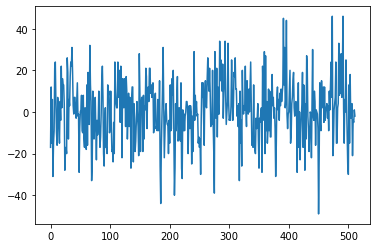

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from pynq import allocate
import time

# 1. Hardware Access
dma = ol.axi_dma_0

# 2. Setup Buffers (Keep it small: 256 samples)
num_samples = 256 
input_buffer = allocate(shape=(num_samples,), dtype=np.uint32)
output_buffer = allocate(shape=(num_samples,), dtype=np.uint32)

# Generate 10MHz wave at 2.4576GHz
t = np.arange(num_samples)
input_buffer[:] = (0x00FF * np.sin(2 * np.pi * 10e6 * t / 2.4576e9) + 0x3FFF).astype(np.uint32)
input_buffer.flush()

# 3. Direct Register Execution
try:
    print("Executing Nuclear Hardware Reset...")
    dma.write(0x00, 0x4) # Reset MM2S
    dma.write(0x30, 0x4) # Reset S2MM
    time.sleep(0.5)
    
    # Start the engines
    dma.write(0x00, 0x1) # Run MM2S
    dma.write(0x30, 0x1) # Run S2MM
    
    print("Writing addresses directly to DMA registers...")
    # MM2S (Send) Registers
    dma.write(0x18, input_buffer.physical_address) # Source Address
    dma.write(0x28, num_samples * 4)               # Length (Bytes)
    
    # S2MM (Recv) Registers
    dma.write(0x48, output_buffer.physical_address) # Destination Address
    dma.write(0x58, num_samples * 4)                # Length (Bytes)
    
    print("Waiting for hardware completion...")
    success = False
    for _ in range(50):
        # Read S2MM_SR (0x34). Bit 12 (0x1000) is Idle/Complete
        status = dma.read(0x34)
        if status & 0x1000:
            success = True
            break
        if status & 0x4010: # Error bits
            print(f"Hardware Error Detected! SR: {hex(status)}")
            break
        time.sleep(0.1)

    if success:
        output_buffer.invalidate()
        print("Success! Data captured.")
        plt.plot(output_buffer.view(np.int16))
        plt.show()
    else:
        print(f"Failed. Final Status - Send: {hex(dma.read(0x04))}, Recv: {hex(dma.read(0x34))}")

except Exception as e:
    print(f"Critical failure: {e}")